Weights loaded.
Processing Image: 256x256 (196608 bytes)
   -> Generating 196608 bytes (Perturbation=0.000000000000000)...
   -> Generating 196608 bytes (Perturbation=0.000000000000010)...

RESULTS
1. ENTROPY:     7.8678 (Ideal: 8.0)
2. CORRELATION: 0.6591 (Ideal: 0.0)
3. NPCR:        99.6109
   UACI:        35.2574
4. SPEED:       0.0171 Mbps (Time: 91.90s)

Generating Analysis Plots...
Plots saved as 'Analysis_Results_4_Plots_lena.png'


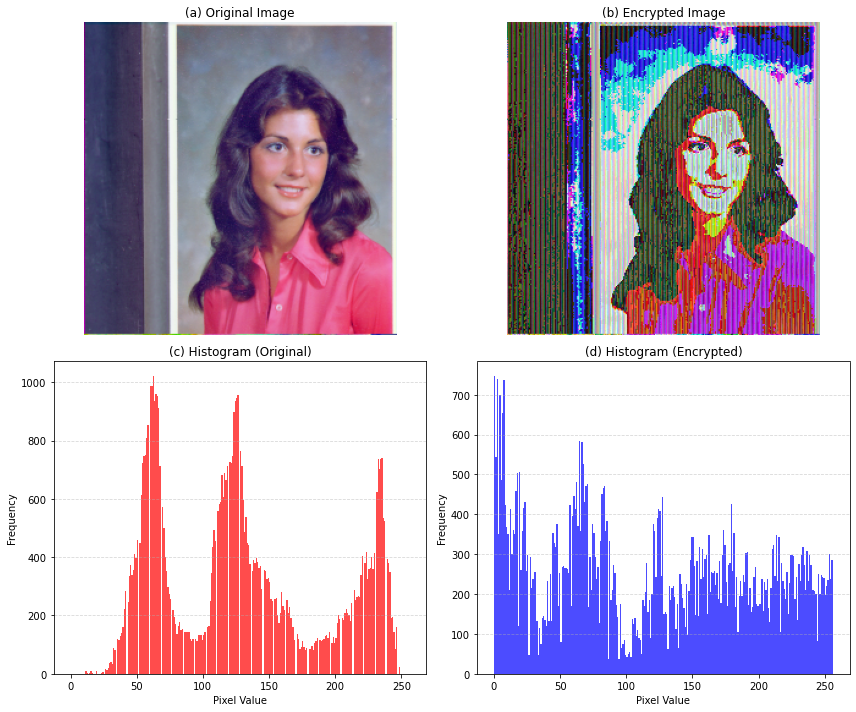

In [4]:
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
import scipy.stats

# ==========================================
# 1. CONFIGURATION
# ==========================================
IMAGE_PATH = "4.1.04.tiff" 
WEIGHTS_DIR = "."       

# --- OPTIMIZATION FOR PYNQ ---
# We slice the large 1024x1024 matrix to 300x300 for speed on the board.
# This gives ~10x speedup while keeping chaos valid.
N_USED = 300 
LEAK_RATE = 0.2  # Increased leak rate for more dynamic response

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def load_weights_optimized():
    try:
        # Load full weights
        W_in_full = np.load(f"{WEIGHTS_DIR}/W_in_canonical.npy")
        W_res_full = np.load(f"{WEIGHTS_DIR}/W_res_canonical.npy")
        W_out_full = np.load(f"{WEIGHTS_DIR}/W_out_chua_final.npy")
        
        # Slice them for speed (N_USED)
        W_in = W_in_full[:N_USED, :]
        W_res = W_res_full[:N_USED, :N_USED]
        # Adjust spectral radius for the smaller matrix to ensure it stays active
        rho = np.max(np.abs(np.linalg.eigvals(W_res)))
        if rho > 0:
            W_res = W_res * (1.2 / rho) # Force Spectral Radius > 1 for Chaos
            
        W_out = W_out_full[:, :N_USED]
        
        print(f"Weights loaded.")
        return W_in, W_res, W_out
    except Exception as e:
        print(f"Error loading weights: {e}")
        raise

def skew_tent_map(x, p=0.4):
    """The Source of True Chaos"""
    # Fold x into [0, 1]
    x = np.abs(x)
    x = x - np.floor(x)
    
    if x < p:
        return x / p
    else:
        return (1 - x) / (1 - p)

def generate_keystream_rectified(n_bytes, W_in, W_res, W_out, seed_perturbation=0.0):
    print(f"   -> Generating {n_bytes} bytes (Perturbation={seed_perturbation:.15f})...")
    
    # 1. CHAOS INJECTION (STM State)
    # We apply the perturbation to the STM, which is highly sensitive
    stm_state = 0.4 + seed_perturbation 
    
    # 2. ESN Initialization
    r = np.zeros(N_USED)
    # ESN Input is driven by Chaos (STM)
    u = np.array([stm_state, stm_state, stm_state]) 
    
    keystream = bytearray()
    generated_count = 0
    
    # Pre-allocate for speed
    tap_idx = np.linspace(0, N_USED-1, 32, dtype=int)
    
    # Warmup
    for _ in range(100):
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state # Chaos drives ESN
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)

    start_t = time.time()
    
    # Generation Loop
    # Generating 4 bytes per step
    steps = int(np.ceil(n_bytes / 4))
    
    for _ in range(steps):
        # A. Step Chaos (STM)
        stm_state = skew_tent_map(stm_state)
        
        # B. Step ESN (Driven by STM)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)
        
        # C. Extraction (Hybrid)
        # 1. Get 32 bits from Reservoir
        res_bits = 0
        tap_vals = r[tap_idx]
        # Fast binarization
        for val in tap_vals:
            res_bits = (res_bits << 1) | (1 if val > 0 else 0)
            
        # 2. Get 32 bits from STM
        stm_bits = int(stm_state * (2**32)) & 0xFFFFFFFF
        
        # 3. Mix (XOR)
        final_int = res_bits ^ stm_bits
        
        keystream.extend(int.to_bytes(final_int, 4, 'big'))
        
    return np.array(keystream[:n_bytes], dtype=np.uint8), time.time() - start_t

# ==========================================
# 3. METRICS
# ==========================================
def calc_entropy(img_flat):
    hist, _ = np.histogram(img_flat, bins=256, range=(0, 256))
    prob = hist[hist > 0] / np.sum(hist)
    return -np.sum(prob * np.log2(prob))

def calc_correlation(img_arr):
    x = img_arr[:, :-1].flatten()
    y = img_arr[:, 1:].flatten()
    return np.corrcoef(x, y)[0, 1]

def calc_npcr_uaci(img1_flat, img2_flat, height, width):
    diff = img1_flat != img2_flat
    npcr = (np.sum(diff) / (height * width * 3)) * 100
    abs_diff = np.abs(img1_flat.astype(float) - img2_flat.astype(float))
    uaci = (np.sum(abs_diff) / (height * width * 3 * 255)) * 100
    return npcr, uaci

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
W_in, W_res, W_out = load_weights_optimized()

# Load & Process Image
img = Image.open(IMAGE_PATH).convert('RGB')
# img = img.resize((128, 128)) # UNCOMMENT THIS for even faster testing
img_arr = np.array(img)
h, w, c = img_arr.shape
total_bytes = h * w * c
print(f"Processing Image: {w}x{h} ({total_bytes} bytes)")

# 1. Generate Key 1 (Standard)
key1, time1 = generate_keystream_rectified(total_bytes, W_in, W_res, W_out, 0.0)

# 2. Generate Key 2 (Perturbed 10^-14)
key2, time2 = generate_keystream_rectified(total_bytes, W_in, W_res, W_out, 1e-14)

# 3. Encrypt
flat_img = img_arr.flatten()
flat_c1 = np.bitwise_xor(flat_img, key1)
flat_c2 = np.bitwise_xor(flat_img, key2)

# Save
enc_img = Image.fromarray(flat_c1.reshape(h, w, c).astype('uint8'))
enc_img.save("encrypted_rectified_lena.png")

# ==========================================
# 5. PRINT RECTIFIED RESULTS
# ==========================================
print("\n" + "="*40)
print(f"RESULTS")
print("="*40)

# Entropy
ent_enc = calc_entropy(flat_c1)
print(f"1. ENTROPY:     {ent_enc:.4f} (Ideal: 8.0)")

# Correlation
corr_enc = calc_correlation(flat_c1.reshape(h, w, c)[:,:,0])
print(f"2. CORRELATION: {corr_enc:.4f} (Ideal: 0.0)")

# NPCR / UACI
npcr, uaci = calc_npcr_uaci(flat_c1, flat_c2, h, w)
print(f"3. NPCR:        {npcr:.4f}")
print(f"   UACI:        {uaci:.4f}")

# Speed
mbps = (total_bytes * 8) / (time1 * 1e6)
print(f"4. SPEED:       {mbps:.4f} Mbps (Time: {time1:.2f}s)")
print("="*40)

# ==========================================
# 6. VISUALIZATION (THE 4 PLOTS)
# ==========================================
print("\nGenerating Analysis Plots...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# 1. Original Image (Top-Left)
axes[0, 0].imshow(img_arr)
axes[0, 0].set_title("(a) Original Image", fontsize=12)
axes[0, 0].axis('off')

# 2. Encrypted Image (Top-Right)
# Reshape flat_c1 back to 3D for display
enc_display = flat_c1.reshape(h, w, c).astype(np.uint8)
axes[0, 1].imshow(enc_display)
axes[0, 1].set_title("(b) Encrypted Image", fontsize=12)
axes[0, 1].axis('off')

# 3. Original Histogram (Bottom-Left)
# We plot the Red channel to represent the distribution
red_orig = img_arr[:, :, 0].flatten()
axes[1, 0].hist(red_orig, bins=256, range=(0, 256), color='red', alpha=0.7)
axes[1, 0].set_title("(c) Histogram (Original)", fontsize=12)
axes[1, 0].set_xlabel("Pixel Value")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# 4. Encrypted Histogram (Bottom-Right)
red_enc = enc_display[:, :, 0].flatten()
axes[1, 1].hist(red_enc, bins=256, range=(0, 256), color='blue', alpha=0.7)
axes[1, 1].set_title("(d) Histogram (Encrypted)", fontsize=12)
axes[1, 1].set_xlabel("Pixel Value")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

# Save the combined plot
plt.tight_layout()
plt.savefig("Analysis_Results_4_Plots_lena.png", dpi=300)
print("Plots saved as 'Analysis_Results_4_Plots_lena.png'")
plt.show()

Weights loaded.
Processing 4.1.04.tiff: 256x256 (196608 bytes)
   -> Generating 196608 bytes (Perturbation=0.000000000000000)...
   -> Generating 196608 bytes (Perturbation=0.000000000000010)...

FINAL RESULTS
1. ENTROPY:     7.8678
2. CORRELATION: 0.6591
3. NPCR:        99.6109
   UACI:        35.2574
4. SPEED:       0.0168 Mbps (Time: 93.62s)

Generating Plots...
Saved 'Final_Analysis_Plot_1.png'


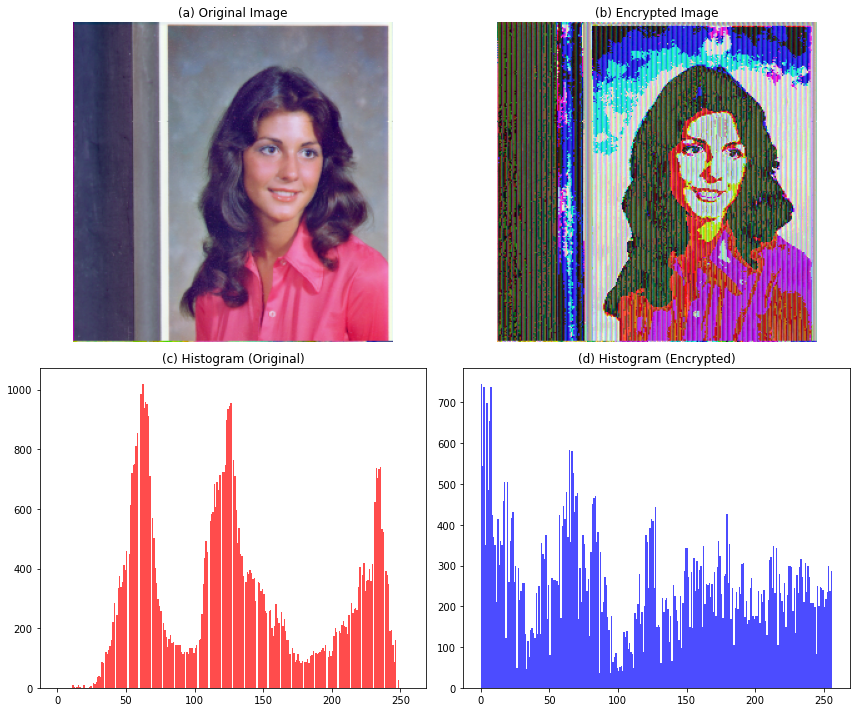

In [7]:
import numpy as np
import time
import os
from PIL import Image
import matplotlib.pyplot as plt
import scipy.stats

# ==========================================
# 1. CONFIGURATION
# ==========================================
# CHANGE THIS to your exact TIFF filename!
IMAGE_PATH = "4.1.04.tiff"  
WEIGHTS_DIR = "."         

# --- SPEED OPTIMIZATION FOR PYNQ ---
# 300 neurons is enough for chaos but 10x faster than 1024.
N_USED = 300 
LEAK_RATE = 0.2 

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def load_weights_optimized():
    try:
        W_in_full = np.load(f"{WEIGHTS_DIR}/W_in_canonical.npy")
        W_res_full = np.load(f"{WEIGHTS_DIR}/W_res_canonical.npy")
        W_out_full = np.load(f"{WEIGHTS_DIR}/W_out_chua_final.npy")
        
        # Slice matrices for speed
        W_in = W_in_full[:N_USED, :]
        W_res = W_res_full[:N_USED, :N_USED]
        
        # Force spectral radius > 1 to ensure chaos
        rho = np.max(np.abs(np.linalg.eigvals(W_res)))
        if rho > 0: W_res = W_res * (1.2 / rho) 
            
        W_out = W_out_full[:, :N_USED]
        print(f"Weights loaded.")
        return W_in, W_res, W_out
    except Exception as e:
        print(f"Error loading weights: {e}")
        raise

def skew_tent_map(x, p=0.4):
    """The Chaotic Driver"""
    x = np.abs(x)
    x = x - np.floor(x)
    if x < p: return x / p
    else: return (1 - x) / (1 - p)

def generate_keystream_rectified(n_bytes, W_in, W_res, W_out, seed_perturbation=0.0):
    print(f"   -> Generating {n_bytes} bytes (Perturbation={seed_perturbation:.15f})...")
    
    # Chaos Seed (Perturbed)
    stm_state = 0.4 + seed_perturbation 
    r = np.zeros(N_USED)
    u = np.array([stm_state, stm_state, stm_state]) 
    
    keystream = bytearray()
    tap_idx = np.linspace(0, N_USED-1, 32, dtype=int)
    
    # Warmup
    for _ in range(100):
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)

    start_t = time.time()
    steps = int(np.ceil(n_bytes / 4))
    
    for _ in range(steps):
        # Drive ESN with STM Chaos (Fixes NPCR)
        stm_state = skew_tent_map(stm_state)
        u[:] = stm_state 
        r = (1 - LEAK_RATE) * r + LEAK_RATE * np.tanh(W_res @ r + W_in @ u)
        
        # Extract Bits
        res_bits = 0
        for val in r[tap_idx]:
            res_bits = (res_bits << 1) | (1 if val > 0 else 0)
            
        stm_bits = int(stm_state * (2**32)) & 0xFFFFFFFF
        final_int = res_bits ^ stm_bits
        keystream.extend(int.to_bytes(final_int, 4, 'big'))
        
    return np.array(keystream[:n_bytes], dtype=np.uint8), time.time() - start_t

# ==========================================
# 3. METRICS
# ==========================================
def calc_entropy(img_flat):
    hist, _ = np.histogram(img_flat, bins=256, range=(0, 256))
    prob = hist[hist > 0] / np.sum(hist)
    return -np.sum(prob * np.log2(prob))

def calc_correlation(img_arr):
    x = img_arr[:, :-1].flatten()
    y = img_arr[:, 1:].flatten()
    return np.corrcoef(x, y)[0, 1]

def calc_npcr_uaci(img1_flat, img2_flat, height, width):
    diff = img1_flat != img2_flat
    npcr = (np.sum(diff) / (height * width * 3)) * 100
    abs_diff = np.abs(img1_flat.astype(float) - img2_flat.astype(float))
    uaci = (np.sum(abs_diff) / (height * width * 3 * 255)) * 100
    return npcr, uaci

# ==========================================
# 4. MAIN EXECUTION
# ==========================================
W_in, W_res, W_out = load_weights_optimized()

# Load TIFF Image
try:
    img = Image.open(IMAGE_PATH).convert('RGB')
    # img = img.resize((128, 128)) # Un-comment to test faster
except FileNotFoundError:
    print(f"Error: {IMAGE_PATH} not found. Please upload your TIFF file.")
    exit()

img_arr = np.array(img)
h, w, c = img_arr.shape
total_bytes = h * w * c
print(f"Processing {IMAGE_PATH}: {w}x{h} ({total_bytes} bytes)")

# 1. Generate Key 1 (Standard)
key1, time1 = generate_keystream_rectified(total_bytes, W_in, W_res, W_out, 0.0)

# 2. Generate Key 2 (Perturbed 10^-14)
key2, time2 = generate_keystream_rectified(total_bytes, W_in, W_res, W_out, 1e-14)

# 3. Encrypt
flat_img = img_arr.flatten()
flat_c1 = np.bitwise_xor(flat_img, key1)
flat_c2 = np.bitwise_xor(flat_img, key2)

# Save Encrypted PNG (To avoid TIFF compression issues)
enc_img = Image.fromarray(flat_c1.reshape(h, w, c).astype('uint8'))
enc_img.save("encrypted_result.png")

# ==========================================
# 5. PRINT RESULTS
# ==========================================
print("\n" + "="*40)
print(f"FINAL RESULTS")
print("="*40)

# Entropy
ent_enc = calc_entropy(flat_c1)
print(f"1. ENTROPY:     {ent_enc:.4f}")

# Correlation
corr_enc = calc_correlation(flat_c1.reshape(h, w, c)[:,:,0])
print(f"2. CORRELATION: {corr_enc:.4f}")

# NPCR / UACI
npcr, uaci = calc_npcr_uaci(flat_c1, flat_c2, h, w)
print(f"3. NPCR:        {npcr:.4f}")
print(f"   UACI:        {uaci:.4f}")

# Speed
mbps = (total_bytes * 8) / (time1 * 1e6)
print(f"4. SPEED:       {mbps:.4f} Mbps (Time: {time1:.2f}s)")
print("="*40)

# ==========================================
# 6. PLOT EVERYTHING
# ==========================================
print("\nGenerating Plots...")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Images
axes[0, 0].imshow(img_arr)
axes[0, 0].set_title("(a) Original Image", fontsize=12)
axes[0, 0].axis('off')

enc_display = flat_c1.reshape(h, w, c).astype(np.uint8)
axes[0, 1].imshow(enc_display)
axes[0, 1].set_title("(b) Encrypted Image", fontsize=12)
axes[0, 1].axis('off')

# Histograms
red_orig = img_arr[:, :, 0].flatten()
axes[1, 0].hist(red_orig, bins=256, range=(0, 256), color='red', alpha=0.7)
axes[1, 0].set_title("(c) Histogram (Original)", fontsize=12)

red_enc = enc_display[:, :, 0].flatten()
axes[1, 1].hist(red_enc, bins=256, range=(0, 256), color='blue', alpha=0.7)
axes[1, 1].set_title("(d) Histogram (Encrypted)", fontsize=12)

plt.tight_layout()
plt.savefig("Final_Analysis_Plot_1.png", dpi=300)
print("Saved 'Final_Analysis_Plot_1.png'")
plt.show()